In [ ]:
# Data Handling and Preprocessing
import pandas as pd  # For loading and manipulating the dataset
import numpy as np   # For numerical operations, including handling arrays

# Data Scaling and Normalization
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder  # For scaling/normalizing the dataset to a range (0, 1), endong categorical data into a binary matrix

from sklearn.compose import ColumnTransformer     # Applying different preprocessing transformations to specific columns in a dataset.
from sklearn.pipeline import Pipeline

#Check for imbalance
from sklearn.impute import SimpleImputer # Handles missing data by replacing it with strategies like mean, median, or mode
from imblearn.over_sampling import SMOTE  # Generates synthetic samples to balance datasets with class imbalances
from imblearn.under_sampling import RandomUnderSampler  # Balances datasets by reducing the size of the majority class through random sampling

# Import the seasonal_decompose function
from statsmodels.tsa.seasonal import seasonal_decompose # Analyzes and visualizes seasonal, trend, and residual components of time-series data.

# Data Splitting
from sklearn.model_selection import train_test_split  # For splitting data into training, validation, and testing sets

# import the math module to access sqrt function.
import math    # Used to compute the root mean squared error (RMSE).
from sklearn.metrics import mean_squared_error  Error metrics (mean_squared_error, mean_absolute_error) evaluate model accuracy

# TensorFlow & Keras for LSTM Model
import tensorflow as tf  # For TensorFlow, which includes the Keras API for building neural networks
from tensorflow.keras.models import Sequential  # To create a linear stack of layers for the model
from tensorflow.keras.layers import  LSTM, Dense  # For LSTM and Dense layers used in the model
from tensorflow.keras.optimizers import Adam # to optimize the model during training by adjusting the weights.

# Model Evaluation and Metrics
from sklearn.metrics import mean_absolute_error,r2_score, mean_absolute_error,   # To evaluate the model's performance using error metrics

# Visualization
import matplotlib.pyplot as plt  #  For basic plots to visualize data and model performance.
import seaborn as sns  # For advanced visualization, especially for statistical plots

This segment imports key libraries and tools required for data preprocessing, handling, visualization, model building, and evaluation, offering a comprehensive foundation for developing a LSTM-based time series machine learning model.bold text

In [ ]:
import pandas as pd  #Imports the Pandas library and assigns it the alias pd
data = pd.read_csv('CrimeDate (1).csv') # Load dataset

This code segment loads the CrimeDate (1).csv (Dataset to be processed and used for time-series analysis) file into a Pandas DataFrame called data(Dataset variable) for analysis and preprocessing

In [ ]:
# Inspect the data
print(data.head())  # Views the first 5 rows of the dataset
print(data.info())  # Checks the column names, data types, and non-null counts
print(data.describe())  # Get summary statistics for numerical columns

       date         primary_type  crime_count  arrest_count  false_count
0  1/1/2001  MOTOR VEHICLE THEFT           59             9           50
1  1/1/2001    WEAPONS VIOLATION           32            26            6
2  1/1/2001   DECEPTIVE PRACTICE           78            16           62
3  1/1/2001    CRIMINAL TRESPASS           29            17           12
4  1/1/2001             GAMBLING            2             2            0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141855 entries, 0 to 141854
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   date          141855 non-null  object
 1   primary_type  141855 non-null  object
 2   crime_count   141855 non-null  int64 
 3   arrest_count  141855 non-null  int64 
 4   false_count   141855 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.4+ MB
None
         crime_count   arrest_count    false_count
count  141855.000000  141855.000000  141855.0

In this part, we are getting an overview about the nature of the dataset by using commands like:

**1 - data.head()**
understand the structure and data samples.

**2- data.info()**
to identify missing values and understanding data types.

**3- data.describe()**
to provide insights into the distribution of crime-related data; includes count,mean,std,min, and percentiles


**Output Analysis:**

data.head():
Dataset contains a "date" column and information about crimes; "primary_type , crime_count, arrest_count, false_count".
Each row corresponds to crime statistics for a specific date and type of crime.

data.info():
 - 141,855 total rows
 - "date" and "primary_type" are of type object (strings).
 - "crime_count, arrest_count, and false_count" are of type int64(integers).
 - All columns have 141,855 non-null values, so there are no missing values.
 - The dataset uses approximately 5.4 MB of memory.

data.describe():

**crime_count:**

 - **Mean**: ~51.6 crimes per type per day.
 - **Median:** 29 (most days have fewer than 30 crimes of a specific type).
 - High standard deviation (~63.7), indicating variability.
 - Max value: 579, suggesting certain types of crimes spike on specific days.

**arrest_count:**

 - **Mean:** ~14.03 arrests per type per day.
 - **Median**: 6, showing most days have fewer than 10 arrests per type.
 - Max value: 559, indicating occasional surges in arrests.

**false_count:**

 - **Mean:** ~37.56 false reports per type per day.
 - **Median**: 9, implying a skewed distribution with occasional high values.
 - **Max value:** 556, pointing to outlier days with significantly high false reports.

 **.** To summarize; the dataset reveals significant variability in daily crime in Chicago . The average daily crime count is ~51.6, with a median of 29, but occasional spikes reach as high as 579. Arrests average ~14.03 per day, typically fewer than 10 (median 6), with a maximum of 559. False reports average ~37.56, with most days below 10 (median 9) but rare extremes up to 556. The differences between the mean and median suggest skewed distributions, likely influenced by outliers that warrant further investigation.

In [ ]:
data['date'] = pd.to_datetime(data['date'], errors='coerce') #Datetime conversion ensures consistent handling of dates.

data.dropna(subset=['date'], inplace=True) #Check if any rows have invalid dates and drop them

print(data['date'].head()) #Confirm the conversion

0   2001-01-01
1   2001-01-01
2   2001-01-01
3   2001-01-01
4   2001-01-01
Name: date, dtype: datetime64[ns]


In this segment, the code aims to convert the date column to a datetime format to ensure data consistency and accurate calculations and insights as well as error handling.

  **pd.to_datetime(data['date'], errors= 'coerce'):**

*   Converts the date column to a datetime format.
errors='coerce' : Any invalid or non-convertible entries are replaced with NaT (Not a Time).

**data.dropna(subset=['date'], inplace=True):**

*   Drops rows where the date column contains NaT (missing or invalid dates).
*   inplace=True ensures the changes are applied directly to the data DataFrame.

**print(data['date'].head()):**

*   Displays the first 5 rows of the date column after conversion and cleaning.

**Output Analysis:**

Shows that the date column was successfully converted to datetime[ns] format, and all values in the sample are valid dates (2001-01-01). Any existing invalid or missig dateshave been dropped as well.

In [ ]:
data.set_index('date', inplace=True) # Set the date as the index

In this part of the code, we set the date as the indes to make time-based operations more efficient, and we also sorted the index to ensure that the data is in chronological order; which is esstential for trend analysis and sequential modeling.

    data.set_index('date', inplace=True):

Sets "date" column as the index of the DataFrame.
Makes "date" the primary reference for accessing rows.
inplace=True modifies the DataFrame directly without creating a copy.

In [ ]:
# Get the unique values in the 'primary_type' column
unique_values = data['primary_type'].unique()

# Print the unique values
print(unique_values)
print(data['primary_type'].nunique())

['MOTOR VEHICLE THEFT' 'WEAPONS VIOLATION' 'DECEPTIVE PRACTICE'
 'CRIMINAL TRESPASS' 'GAMBLING' 'ROBBERY' 'BURGLARY'
 'INTERFERENCE WITH PUBLIC OFFICER' 'PUBLIC PEACE VIOLATION'
 'LIQUOR LAW VIOLATION' 'CRIMINAL SEXUAL ASSAULT' 'THEFT' 'NARCOTICS'
 'ASSAULT' 'OTHER OFFENSE' 'BATTERY' 'CRIMINAL DAMAGE'
 'OFFENSE INVOLVING CHILDREN' 'STALKING' 'SEX OFFENSE' 'PROSTITUTION'
 'HOMICIDE' 'ARSON' 'OBSCENITY' 'DOMESTIC VIOLENCE' 'KIDNAPPING'
 'OTHER NARCOTIC VIOLATION' 'INTIMIDATION' 'PUBLIC INDECENCY' 'RITUALISM'
 'NON-CRIMINAL' 'NON-CRIMINAL (SUBJECT SPECIFIED)' 'HUMAN TRAFFICKING'
 'CONCEALED CARRY LICENSE VIOLATION']
34


In this segment of the code, we are identifying unique values in "primary_type" ; this aids in preparing us for tasks like one-hot encoding or aggregation.

    data['primary_type'].unique():

Retrieves all unique values in "primary_type" .
Returns them as a NumPy array, providing a list of all distinct crime categories present in the dataset.

    data['primary_type'].nunique():

Calculates the total number of unique values in "primary_type".
Gives the count of distinct crime categories.


**Output Analysis:**

 - All 34 distinct crime categories (e.g., ‘MOTOR VEHICLE THEFT’, ‘ASSAULT’, ‘BURGLARY’) are displayed to help us understand the types of crimes in our dataset.

 - Indicates that there are 34 unique crime categories in all of the dataset.

Outliers in 'crime_count':
               primary_type  crime_count  arrest_count  false_count
date                                                               
2001-01-01            THEFT          404            38          366
2001-01-01    OTHER OFFENSE          166            14          152
2001-01-01          BATTERY          294            79          215
2001-01-01  CRIMINAL DAMAGE          233            20          213
2001-01-02        NARCOTICS          175           175            0
...                     ...          ...           ...          ...
2022-05-16            THEFT          170             8          162
2022-05-17            THEFT          168             6          162
2022-05-19            THEFT          166            10          156
2022-05-30          BATTERY          182            36          146
2022-06-07            THEFT          171             5          166

[11102 rows x 4 columns]


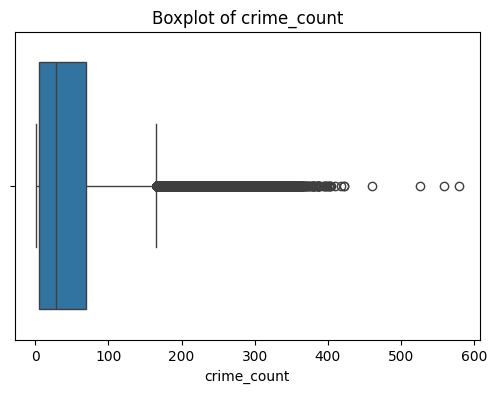

Outliers in 'arrest_count':
                 primary_type  crime_count  arrest_count  false_count
date                                                                 
2001-01-01              THEFT          404            38          366
2001-01-01          NARCOTICS           96            96            0
2001-01-01            BATTERY          294            79          215
2001-01-02            BATTERY          142            40          102
2001-01-02          NARCOTICS          175           175            0
...                       ...          ...           ...          ...
2022-01-01            BATTERY          138            33          105
2022-05-28  WEAPONS VIOLATION           43            34            9
2022-05-29  WEAPONS VIOLATION           58            38           20
2022-05-30            BATTERY          182            36          146
2022-05-30  WEAPONS VIOLATION           62            47           15

[14050 rows x 4 columns]


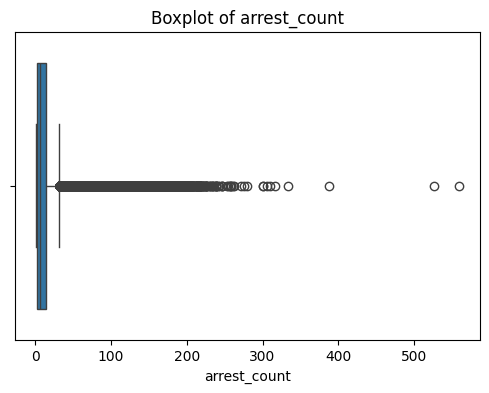

Outliers in 'false_count':
               primary_type  crime_count  arrest_count  false_count
date                                                               
2001-01-01            THEFT          404            38          366
2001-01-01    OTHER OFFENSE          166            14          152
2001-01-01          BATTERY          294            79          215
2001-01-01  CRIMINAL DAMAGE          233            20          213
2001-01-02            THEFT          221            33          188
...                     ...          ...           ...          ...
2022-06-10            THEFT          138             3          135
2022-06-11          BATTERY          141            11          130
2022-06-12          BATTERY          164            28          136
2022-06-13            THEFT          153             5          148
2022-06-14            THEFT          139            10          129

[12618 rows x 4 columns]


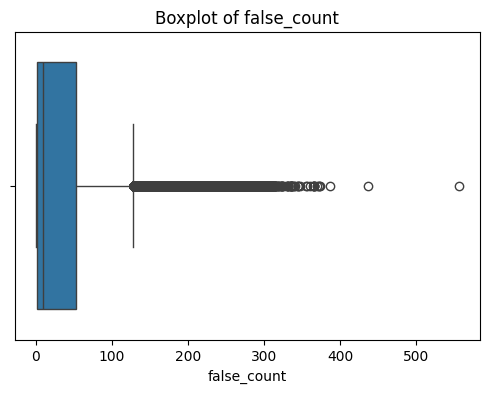

In [ ]:
# Import matplotlib.pyplot inside the function if it's not already imported
import matplotlib.pyplot as plt  # Import here to ensure availability
import seaborn as sns #Import seaborn and alias it as sns

# Function to detect outliers using the IQR method
def detect_outliers_iqr(data):
    # Loop through numerical columns
    for col in ['crime_count', 'arrest_count', 'false_count']:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

        # Print outliers for each feature
        print(f"Outliers in '{col}':")
        print(outliers)

        # Visualize outliers using a box plot
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=data[col])
        plt.title(f'Boxplot of {col}')
        plt.show()

# Call the function to detect outliers
detect_outliers_iqr(data)

In [ ]:
# Function to handle outliers using IQR
def handle_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Apply outlier handling for each relevant feature
data = handle_outliers_iqr(data, 'crime_count')
data = handle_outliers_iqr(data, 'arrest_count')
data = handle_outliers_iqr(data, 'false_count')

In [ ]:
# Check the shape of the data after outlier removal
print(f"Data shape after outlier removal: {data.shape}")
print(data.head(10))

Data shape after outlier removal: (114417, 4)
                                primary_type  crime_count  arrest_count  \
date                                                                      
2001-01-01               MOTOR VEHICLE THEFT           59             9   
2001-01-01                DECEPTIVE PRACTICE           78            16   
2001-01-01                 CRIMINAL TRESPASS           29            17   
2001-01-01                          GAMBLING            2             2   
2001-01-01                           ROBBERY           40             5   
2001-01-01                          BURGLARY           65             5   
2001-01-01  INTERFERENCE WITH PUBLIC OFFICER            1             1   
2001-01-01            PUBLIC PEACE VIOLATION            5             2   
2001-01-01              LIQUOR LAW VIOLATION            3             3   
2001-01-01           CRIMINAL SEXUAL ASSAULT           35            12   

            false_count  
date                     
2

This part of the code displays the data shape after we have done outlier removal to show its effectiveness and to highlight the amount of data retained for analysis. When previewing the data, it ensures that the cleaned dataset is structured correctly and is ready for further processing or analysis.

    print(f"Data shape after outlier removal: {data.shape}"):

Displays the shape of "data" after outlier removal.

data.shape returns a tuple (rows, columns) indicating the number of rows and columns in the dataset.

    print(data.head(10)):

Displays the first 10 rows of the DataFrame to show a preview of the data after cleaning and outlier removal.

Provide a quick look at the structure, column names, and sample values.

**Output Analysis:**

After removing outliers, the dataset contains 114,417 rows and 4 columns; indicating that outlier removal significantly reduced the number of rows compared to the original dataset (141855 rows)

In [ ]:
# Aggregate the data by date and primary_type
agg_data = data.groupby(['date', 'primary_type']).sum().reset_index()

# Display the aggregated data
print(agg_data.head(10))

        date                      primary_type  crime_count  arrest_count  \
0 2001-01-01                           ASSAULT           70            20   
1 2001-01-01                          BURGLARY           65             5   
2 2001-01-01           CRIMINAL SEXUAL ASSAULT           35            12   
3 2001-01-01                 CRIMINAL TRESPASS           29            17   
4 2001-01-01                DECEPTIVE PRACTICE           78            16   
5 2001-01-01                          GAMBLING            2             2   
6 2001-01-01  INTERFERENCE WITH PUBLIC OFFICER            1             1   
7 2001-01-01              LIQUOR LAW VIOLATION            3             3   
8 2001-01-01               MOTOR VEHICLE THEFT           59             9   
9 2001-01-01        OFFENSE INVOLVING CHILDREN           87            13   

   false_count  
0           50  
1           60  
2           23  
3           12  
4           62  
5            0  
6            0  
7            0  

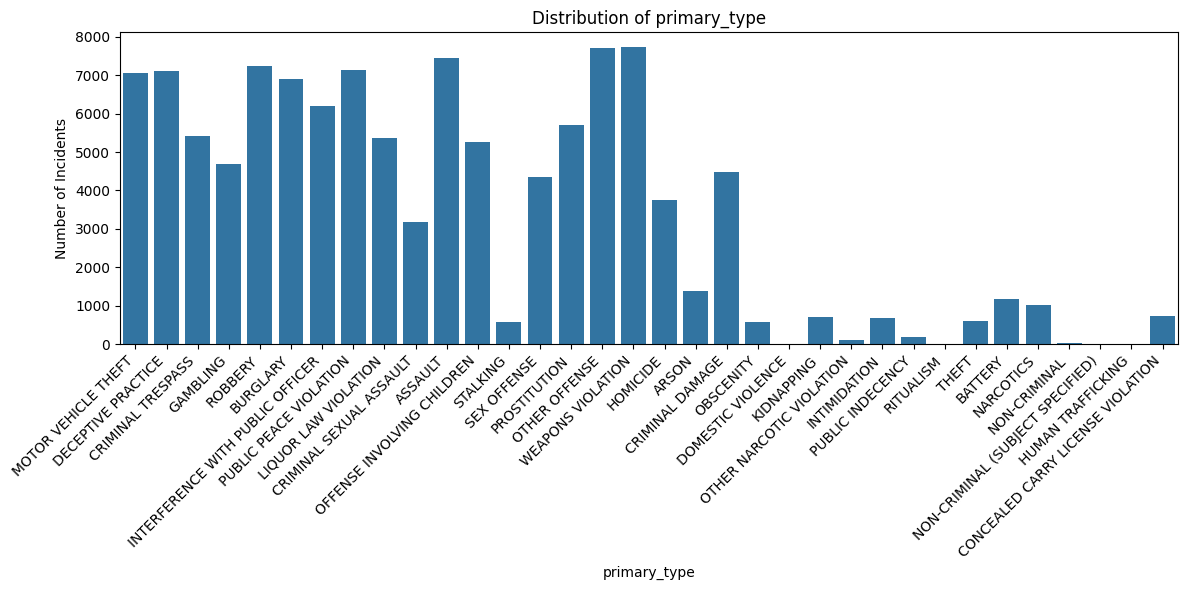

In [ ]:
categorical_features = ['primary_type']

for feature in categorical_features:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=data, x=feature)
    plt.title(f'Distribution of {feature}')
    plt.xticks(rotation=45, ha='right')  # Rotate labels and align them to the right
    plt.ylabel('Number of Incidents')
    plt.tight_layout()  # Adjust layout to prevent clipping of tick-labels
    plt.show()


In this part of the code, we are aiming to visualize the categorical features ("primary_type") in the dataset to find the most suitable approach to handle the imbalances in the dataset and compare the frequencies of differnt crime types through a count plot.

    categorical_features =['primary_type']:

Creates a list of "primary_type" ;representing crime categories, to visalize.

    for feature in categorical_features::

Iterates through each feature in the list to create individual visualizations.

This allows scalability if more categorical columns are added later.

    plt.figure(figsize=(12, 6)):
Sets the figure size for the plot.

    sns.countplot(data=data, x=feature):
Creates a count plot using Seaborn, displaying the number of incidents for each category in "primary_type"

    plt.title(f'Distribution of {feature}'):
Sets the plot title dynamically based on the feature being visualized(primary_type).

    plt.xticks(rotation=45, ha='right'):

Rotates the x-axis labels by 45 degrees and aligns them to the right for better readability and so that no overlap between the labels occur.

    plt.ylabel('Number of Incidents'):
Labels the y-axis to indicate the count of incidents.

    plt.tight_layout():
Adjusts subplot parameters to ensure the elements fit well within the figure.

    plt.show():

Displays the plot.

**Output Analysis:**

 - The plot, titled “Distribution of primary_type,” shows the count of incidents for each crime category (primary_type).

 - Each crime type is displayed along the x-axis. e.g. (“MOTOR VEHICLE THEFT,” “WEAPONS VIOLATION,” and “BURGLARY.”).

 - The y-axis represents the number of incidents for each crime type.

**Key Observations:**

 - Categories like “WEAPONS VIOLATION” and “OTHER OFFENSE” show the highest number of incidents, exceeding 7,000.

 - Rare crimes like “RITUALISM,” “NON-CRIMINAL,” and “HUMAN TRAFFICKING” have extremely low counts, close to zero.

 - Categories like “BURGLARY,” “MOTOR VEHICLE THEFT,” and “ASSAULT” have moderate counts between 4,000–7,000.

 - The distribution is heavily skewed, with a few categories dominating the count (e.g., “WEAPONS VIOLATION”), while many others have significantly fewer incidents.

In [ ]:
print(data['primary_type'].value_counts())

primary_type
WEAPONS VIOLATION                    7730
OTHER OFFENSE                        7700
ASSAULT                              7451
ROBBERY                              7252
PUBLIC PEACE VIOLATION               7131
DECEPTIVE PRACTICE                   7119
MOTOR VEHICLE THEFT                  7061
BURGLARY                             6906
INTERFERENCE WITH PUBLIC OFFICER     6199
PROSTITUTION                         5701
CRIMINAL TRESPASS                    5417
LIQUOR LAW VIOLATION                 5361
OFFENSE INVOLVING CHILDREN           5259
GAMBLING                             4693
CRIMINAL DAMAGE                      4475
SEX OFFENSE                          4348
HOMICIDE                             3759
CRIMINAL SEXUAL ASSAULT              3177
ARSON                                1368
BATTERY                              1160
NARCOTICS                            1013
CONCEALED CARRY LICENSE VIOLATION     718
KIDNAPPING                            706
INTIMIDATION         

Here, we are trying to get a clearer look on the numbers that were displayed in the count plot by having them displayed numerically.

         data['primary_type'].value_counts():

Counts the occurrences of each unique value in "primary_type".
Returns the counts in descending order, showing the most frequent crime categories first.

    print():

Displays the result, which lists each crime type and its total count.

**Output Analysis:**

The output shows the frequency of each crime type in the dataset.

**For example:**

WEAPONS VIOLATION: Most common crime type with 7,730 incidents.
DOMESTIC VIOLENCE: Least common crime type with only 1 incident.
This ranking provides a clear overview of crime distribution.

In [ ]:
import pandas as pd
from sklearn.utils import resample

# Identify the most frequent category count
max_count = data['primary_type'].value_counts().max()

# Function to oversample each category in 'primary_type'
def oversample_primary_type(data):
    oversampled_data = []
    for category in data['primary_type'].unique():
        category_data = data[data['primary_type'] == category]
        oversampled = resample(category_data, replace=True, n_samples=max_count, random_state=42)
        oversampled_data.append(oversampled)
    return pd.concat(oversampled_data)

# Apply oversampling
balanced_data = oversample_primary_type(data)

print("Original dataset shape:", data.shape)
print("Balanced dataset shape:", balanced_data.shape)
print(balanced_data['primary_type'].value_counts())

Original dataset shape: (114417, 4)
Balanced dataset shape: (262820, 4)
primary_type
MOTOR VEHICLE THEFT                  7730
PUBLIC INDECENCY                     7730
CRIMINAL DAMAGE                      7730
OBSCENITY                            7730
DOMESTIC VIOLENCE                    7730
KIDNAPPING                           7730
OTHER NARCOTIC VIOLATION             7730
INTIMIDATION                         7730
RITUALISM                            7730
DECEPTIVE PRACTICE                   7730
THEFT                                7730
BATTERY                              7730
NARCOTICS                            7730
NON-CRIMINAL                         7730
NON-CRIMINAL (SUBJECT SPECIFIED)     7730
HUMAN TRAFFICKING                    7730
ARSON                                7730
HOMICIDE                             7730
WEAPONS VIOLATION                    7730
OTHER OFFENSE                        7730
PROSTITUTION                         7730
SEX OFFENSE                      

The code balances the dataset by oversampling categories in the primary_type column to ensure all crime types have the same number of samples as the most frequent category.As well as, to prevent bias from occuring in the model toward dominant categories and to get the model to learn equally about all categories.

    max_count = data['primary_type'].value_counts().max()
Calculates the maximum number of samples in the most frequent category of primary_type and uses that value as the target sample size for all categories. (WEAPONS VIOLATION)  

Defining Oversampling Function:

    oversampled_data = []

stores oversampled data for each category.

    for category in data['primary_type'].unique():
    For each unique crime type in "primary_type", filter its rows using -> category_data = data[data['primary_type'] == category]
    oversampled = resample(category_data,replace=True, n_samples=max_count, random_state=42)
    resample()
 function duplicates rows from smaller categories until their count equals max_count.

replace=True allows duplication, ensuring categories with fewer samples are adequately expanded.

n_samples=max_count ensures the oversampled category matches the largest category.

random_state=42 ensures consistent random sampling for reproducibility.

    oversampled_data.append(oversampled)
Add each oversampled category to the oversampled_data list.

    return pd.concat(oversampled_data)

Combine all balanced categories into a single dataset using

** Output Analysis:**

- Before Balancing:

The dataset is dominated by categories like "WEAPONS VIOLATION," while others like "HUMAN TRAFFICKING" and "DOMESTIC VIOLENCE" have very few samples, leading to model bias.

- After Balancing:

The dataset becomes balanced, with every category having exactly 7,730 samples. This ensures fair training of the model across all crime types.

In [ ]:
print(data.describe())

         crime_count   arrest_count    false_count
count  114417.000000  114417.000000  114417.000000
mean       27.650603       5.849804      21.800799
std        28.320255       5.381128      26.347894
min         1.000000       1.000000       0.000000
25%         4.000000       2.000000       0.000000
50%        15.000000       4.000000       6.000000
75%        46.000000       8.000000      40.000000
max       130.000000      24.000000     106.000000


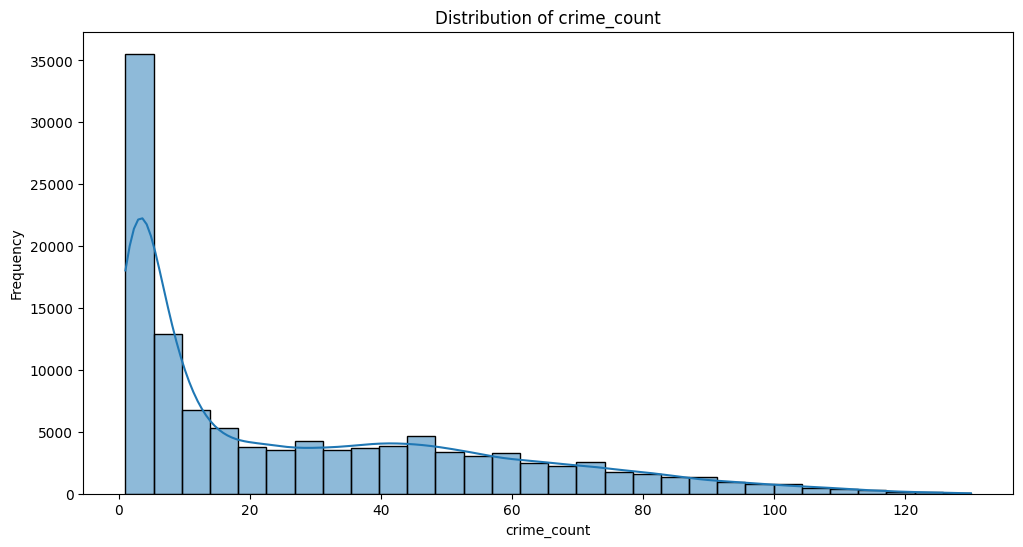

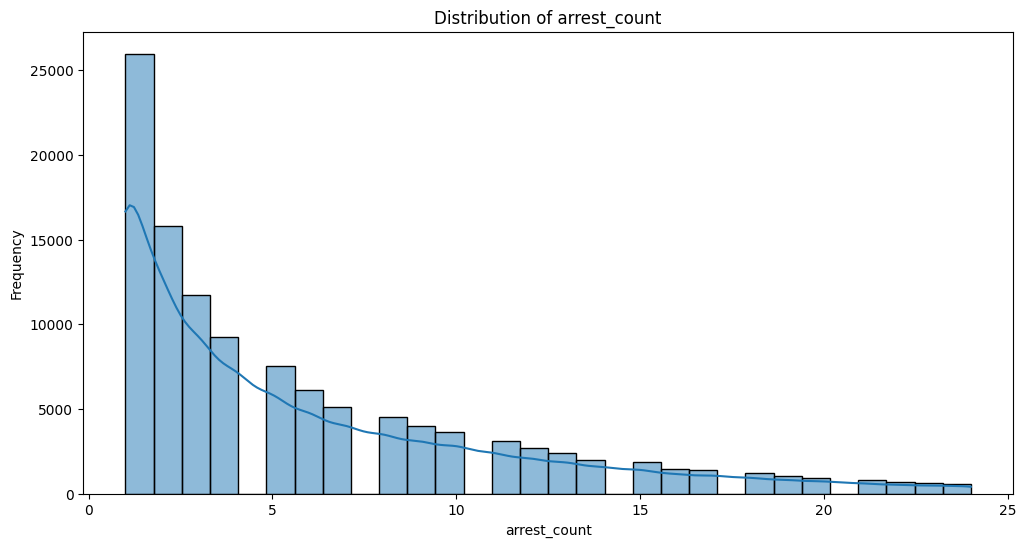

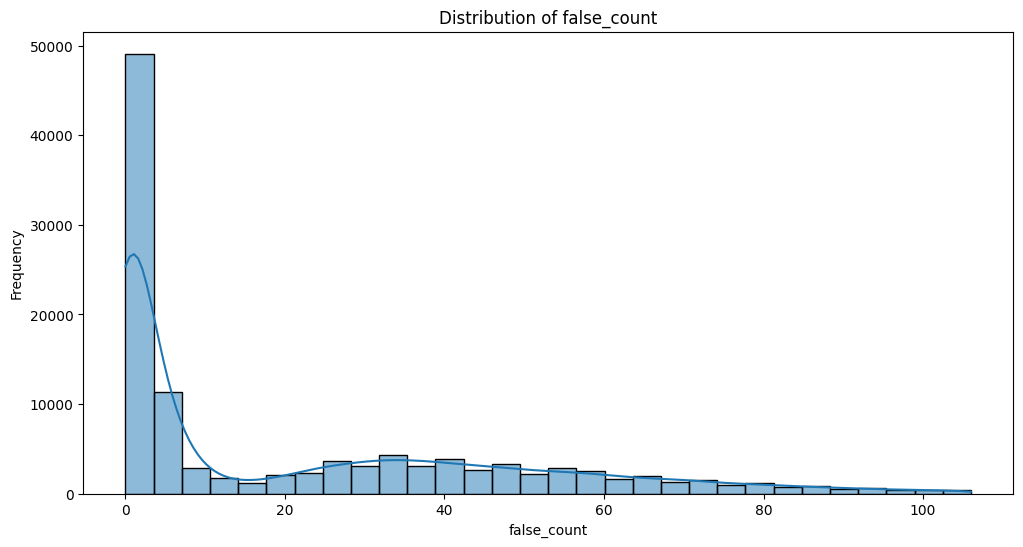

In [ ]:
# Check for imbalance in numerical features (excluding 'arrest')
numerical_features = ['crime_count', 'arrest_count', 'false_count']  # Exclude 'arrest'

for feature in numerical_features:
    plt.figure(figsize=(12, 6))
    sns.histplot(agg_data[feature], bins=30, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
# Specify the numerical features to handle
numerical_features = ['crime_count', 'arrest_count', 'false_count']  # Replace with your actual numerical feature names

# Step 1: Log Transformation (to reduce skewness)
for feature in numerical_features:
    agg_data[feature] = agg_data[feature].apply(lambda x: np.log1p(x))  # log1p handles zero values

# Check the transformed data
print(agg_data[numerical_features].describe())

         crime_count   arrest_count    false_count
count  114417.000000  114417.000000  114417.000000
mean        2.722189       1.643301       2.088450
std         1.233496       0.744731       1.636798
min         0.693147       0.693147       0.000000
25%         1.609438       1.098612       0.000000
50%         2.772589       1.609438       1.945910
75%         3.850148       2.197225       3.713572
max         4.875197       3.218876       4.672829


In [ ]:
# One-hot encode the 'primary_type' column
agg_data_ohe = pd.get_dummies(agg_data, columns=['primary_type'], drop_first=True)

# Display the first few rows of the transformed data
print(agg_data_ohe.head())

        date  crime_count  arrest_count  false_count  primary_type_ASSAULT  \
0 2001-01-01     4.262680      3.044522     3.931826                  True   
1 2001-01-01     4.189655      1.791759     4.110874                 False   
2 2001-01-01     3.583519      2.564949     3.178054                 False   
3 2001-01-01     3.401197      2.890372     2.564949                 False   
4 2001-01-01     4.369448      2.833213     4.143135                 False   

   primary_type_BATTERY  primary_type_BURGLARY  \
0                 False                  False   
1                 False                   True   
2                 False                  False   
3                 False                  False   
4                 False                  False   

   primary_type_CONCEALED CARRY LICENSE VIOLATION  \
0                                           False   
1                                           False   
2                                           False   
3                 

In [ ]:
#Normalization
numerical_features = ['crime_count', 'arrest_count', 'false_count']  # Replace with your actual numerical feature names
scaler = MinMaxScaler()
agg_data[numerical_features] = scaler.fit_transform(agg_data[numerical_features])

In [ ]:
# Check the transformed data
print(agg_data.describe())

                                date    crime_count   arrest_count  \
count                         114417  114417.000000  114417.000000   
mean   2011-07-04 21:00:29.544560384       0.485179       0.376190   
min              2001-01-01 00:00:00       0.000000       0.000000   
25%              2006-04-07 00:00:00       0.219101       0.160534   
50%              2011-07-07 00:00:00       0.497230       0.362783   
75%              2016-09-06 00:00:00       0.754893       0.595502   
max              2022-06-14 00:00:00       1.000000       1.000000   
std                              NaN       0.294950       0.294858   

         false_count  
count  114417.000000  
mean        0.446935  
min         0.000000  
25%         0.000000  
50%         0.416431  
75%         0.794716  
max         1.000000  
std         0.350280  


In [ ]:
# Inspect the data
print(agg_data.head())  # Views the first 5 rows of the dataset
print(agg_data.info())  # Checks the column names, data types, and non-null counts
print(agg_data.describe())  # Get summary statistics for numerical columns

        date             primary_type  crime_count  arrest_count  false_count
0 2001-01-01                  ASSAULT     0.853537      0.930969     0.841423
1 2001-01-01                 BURGLARY     0.836075      0.434968     0.879740
2 2001-01-01  CRIMINAL SEXUAL ASSAULT     0.691138      0.741094     0.680113
3 2001-01-01        CRIMINAL TRESPASS     0.647541      0.869937     0.548907
4 2001-01-01       DECEPTIVE PRACTICE     0.879067      0.847306     0.886644
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114417 entries, 0 to 114416
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          114417 non-null  datetime64[ns]
 1   primary_type  114417 non-null  object        
 2   crime_count   114417 non-null  float64       
 3   arrest_count  114417 non-null  float64       
 4   false_count   114417 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 4.

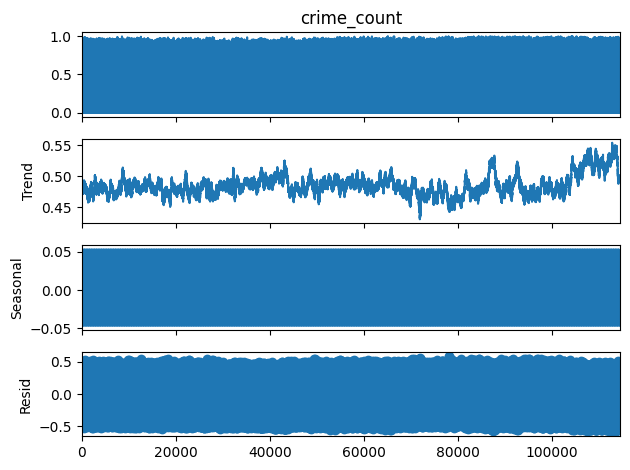

In [ ]:
# Assuming 'crime_count' is the time series to decompose
decomp_annual = seasonal_decompose(agg_data['crime_count'], model='additive', period=365)

# Plot the decomposition
decomp_annual.plot()
plt.show()

In [ ]:
duplicates = agg_data.duplicated(subset=['date', 'primary_type']).sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


In [ ]:
# Define the target variable and features
target_variable = 'crime_count'  # Ensure this matches the column name in agg_data
if target_variable in agg_data.columns:
    X = agg_data.drop([target_variable, 'date'], axis=1)  # Features # Drop 'date' here
    y = agg_data[target_variable]  # Target variable
else:
    print(f"Column '{target_variable}' not found in aggregated data.")

X = agg_data.drop([target_variable, 'date'], axis=1)  # Features

In [ ]:
# Define the split indices
train_size = int(len(agg_data) * 0.7)
val_size = int(len(agg_data) * 0.15)

# Split the data into X (features) and y (target)
X_train, X_val, X_test = X[:train_size], X[train_size:train_size + val_size], X[train_size + val_size:]
y_train, y_val, y_test = y[:train_size], y[train_size:train_size + val_size], y[train_size + val_size:]

# Reshape inputs for LSTM (after data type conversion)
train_X = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))  # Reshape to (samples, timesteps, features)
val_X = X_val.values.reshape((X_val.shape[0], 1, X_val.shape[1]))
test_X = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Check the sizes of the splits
print(f"Training set size: {X_train.shape[0]} samples, {y_train.shape[0]} target values")
print(f"Validation set size: {X_val.shape[0]} samples, {y_val.shape[0]} target values")
print(f"Test set size: {X_test.shape[0]} samples, {y_test.shape[0]} target values")

Training set size: 80091 samples, 80091 target values
Validation set size: 17162 samples, 17162 target values
Test set size: 17164 samples, 17164 target values


In [ ]:
# Step 1: Load and Normalize the Data
# -------------------------------------------------------
# Select relevant columns and reshape data for scaling
data = agg_data[['crime_count', 'arrest_count', 'false_count']].values.reshape(-1, 1)

# Normalize the data to a range between 0 and 1 for better training
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

--------------------------------------------------------------------------------------------------------Code Analysis ----------------------------------------------------------------------------
1. Data Selection and Reshaping

  Selecting Relevant Columns:

data = agg_data[['crime_count','arrest_count','false_count']].values.reshape(-1, 1)

This line extracts the specified columns (crime_count, arrest_count, and false_count) from the agg_data DataFrame. The values method converts the DataFrame into a NumPy array, and reshape(-1, 1) reshapes the array into a two-dimensional format suitable for scaling.

2. Normalization Process

  Creating the Scaler:

    scaler = MinMaxScaler()

  This line initializes a MinMaxScaler object, which will be used to scale the data. The MinMaxScaler transforms features by scaling them to a given range, typically between 0 and 1.


  Fitting and Transforming the Data:

      data_scaled = scaler.fit_transform(data)

This line applies the scaler to the data. The fit_transform method computes the minimum and maximum values of the data and then scales the data accordingly. The result is stored in data_scaled, which contains the normalized values.




-------------------------------------------------------------------------------------------  Output Analysis --------------------------------------------------------------------------

The output of the normalization process will be a NumPy array (data_scaled) where each value is transformed to fit within the range of 0 to 1. Here are the

In [ ]:
# Step 2: Prepare Data for LSTM
# -------------------------------------------------------
# Function to prepare data for LSTM
def prepare_data_for_lstm(data, n_steps):
    """
    Convert a time-series dataset into sequences of length `n_steps`.
    Each sequence (X) is paired with the value immediately following it (y).
    """
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data[i:i + n_steps])
        y.append(data[i + n_steps])
    return np.array(X), np.array(y)

# Define the number of steps (sequence length) and features
n_steps = 10  # Number of time steps to consider for prediction
n_features = 1  # Only one feature per timestep

# Split data into training and testing sets (80% train, 20% test)
train_len = int(len(data_scaled) * 0.8)
train_data = data_scaled[:train_len]
test_data = data_scaled[train_len:]

# Prepare training and testing data for LSTM
X_train, y_train = prepare_data_for_lstm(train_data, n_steps)
X_test, y_test = prepare_data_for_lstm(test_data, n_steps)

# Reshape data to the format required by LSTM: (samples, time_steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], n_features))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], n_features))

--------------------------------------------------------------------------------------------Code Analysis ------------------------------------------------------------------------

1. Function Definition

The function prepare_data_for_lstm is designed to convert a time-series dataset into sequences suitable for training an LSTM model.

 Here’s a breakdown of the key components:

     def prepare_data_for_lstm(data, n_steps):
The function takes two parameters:

- data: The time-series dataset, which is expected to be a 1D array (e.g., a NumPy array).

- n_steps: The number of time steps to consider for each input sequence.

2. Data Preparation Logic
Initialization:
     
        X, y = [], []

Two empty lists, X and y, are initialized to store the input sequences and the corresponding target values.

Looping Through Data:

       for i in range(len(data) - n_steps):
             X.append(data[i:i + n_steps])
             y.append(data[i + n_steps])
This loop iterates through the dataset, creating sequences of length n_steps:

For each index i, a sequence of the next n_steps values is appended to X.
The value immediately following this sequence (i.e., data[i + n_steps]) is appended to y.

This effectively creates a supervised learning problem where the model learns to predict the next value based on the previous n_steps values.

Return Statement:

       return np.array(X), np.array(y)

The function returns the input sequences X and the target values y as NumPy arrays, which are suitable for training the LSTM model.


3. Defining Parameters

Number of Steps and Features:

  - n_steps = 10  # Number of time steps to consider for prediction
  - n_features = 1  # Only one feature per timestep
  - n_steps is set to 10, meaning the model will use the previous 10 time steps to predict the next value.

n_features is set to 1, indicating that there is only one feature per time step (e.g., a single time series).

4. Data Splitting

Splitting Data into Training and Testing Sets:

       train_len = int(len(data_scaled) * 0.8)
       train_data = data_scaled[:train_len]
       test_data = data_scaled[train_len:]

The dataset is split into training and testing sets, with 80% of the data used for training and 20% for testing. This is a common practice to ensure that the model is evaluated on unseen data.

5. Preparing Data for LSTM

Preparing Training and Testing Data:

      X_train, y_train = prepare_data_for_lstm(train_data, n_steps)
      X_test, y_test = prepare_data_for_lstm(test_data, n_steps)

The prepare_data_for_lstm function is called for both the training and testing datasets to create the input-output pairs.

6. Reshaping Data

Reshaping for LSTM Input:

     X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], n_features))
     X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], n_features))

The input data is reshaped to the format required by LSTM models, which is (samples, time_steps, features).

This ensures that the LSTM can process the sequences correctly.

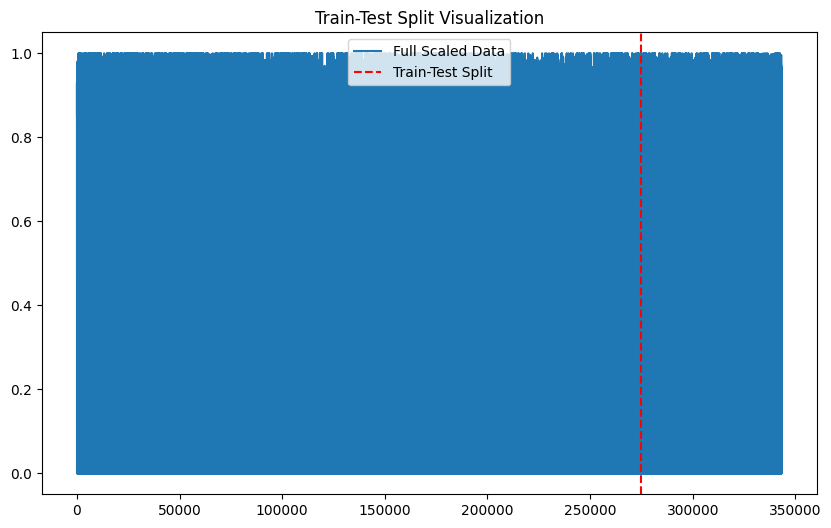

In [ ]:
# Step 3: Visualize Data Split
# -------------------------------------------------------
# Visualization of the split between train and test data
plt.figure(figsize=(10, 6))
plt.plot(data_scaled, label="Full Scaled Data")
plt.axvline(x=train_len, color='red', linestyle='--', label="Train-Test Split")
plt.title("Train-Test Split Visualization")
plt.legend()
plt.show()

**Code Analysis**

1. Visualization Setup

The code snippet is responsible for creating a line plot that visualizes the full scaled dataset and indicates where the training and testing splits occur.

Here’s a breakdown of the key components:

Figure Creation:

     plt.figure(figsize=(10, 6))

This line initializes a new figure for the plot with a specified size of 10 inches wide and 6 inches tall. This size is generally suitable for visualizing time series data, providing enough space for clarity.

2. Plotting the Full Scaled Data

Plotting the Data:

      plt.plot(data_scaled, label="Full Scaled Data")

This line plots the entire scaled dataset (data_scaled) as a line graph. The label parameter is set to "Full Scaled Data," which will be used in the legend to identify this line.

3. Indicating the Train-Test Split

Vertical Line for Split:

     plt.axvline(x=train_len, color='red', linestyle='--', label="Train-Test Split")

This line adds a vertical dashed line at the position of train_len, which indicates where the training data ends and the testing data begins. The line is colored red and labeled "Train-Test Split" for clarity.

4. Adding Titles and Legends

Title:

        plt.title("Train-Test Split Visualization")
This line sets the title of the plot, providing context for what the viewer is looking at.

Legend:

     plt.legend()
This line adds a legend to the plot, which helps differentiate between the full scaled data and the train-test split line based on the labels provided earlier.

5. Displaying the Plot

Show Plot:

     plt.show()
This line renders the plot and displays it to the user. It is the final step in the visualization process.

In [ ]:
# Step 4: Define LSTM Model
# -------------------------------------------------------
# Function to create an LSTM model with tunable hyperparameters
def create_lstm_model(input_shape, units, learning_rate):
    """
    Create an LSTM model with specified units and learning rate.
    """
    model = Sequential([
        LSTM(units=units, activation='tanh', recurrent_activation='sigmoid', input_shape=input_shape),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')  # Regression output
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model


**Code Analysis**

**1. Function Definition**

 The function create_lstm_model is designed to create and return a Sequential LSTM model with specified hyperparameters.

  Here’s a breakdown of the key components:

 - Function Signature:

            [ def create_lstm_model(input_shape, units, learning_rate)]


The function takes three parameters:
 - input_shape: The shape of the input data, typically defined as (n_steps, n_features), where n_steps is the number of time steps and n_features is the number of features at each time step.

 - units: The number of LSTM units (neurons) in the LSTM layer.

 - learning_rate: The learning rate for the optimizer, which controls how much to change the model in response to the estimated error each time the model weights are updated.

**2. Model Architecture**

Sequential Model:

     model = Sequential([

This line initializes a Sequential model, which is a linear stack of layers. It is suitable for building models layer by layer.

LSTM Layer:

       LSTM(units=units, activation='tanh', recurrent_activation='sigmoid', input_shape=input_shape)

This line adds an LSTM layer to the model with the following parameters:

- units=units: The number of LSTM units specified by the user.

- activation='tanh': The activation function for the LSTM cell, which helps in squashing the output to a range between -1 and 1.

- recurrent_activation='sigmoid': The activation function used for the recurrent step, which helps in determining the output of the LSTM cell.

**input_shape=input_shape:** Specifies the shape of the input data. This is required for the first layer in a Sequential model.

Dense Layers:

- Dense(32, activation='relu'),
- Dense(1, activation='linear')  # Regression output

The first Dense layer has 32 units and uses the ReLU (Rectified Linear Unit) activation function. This layer introduces non-linearity and allows the model to learn complex patterns.

The second Dense layer has a single unit with a linear activation function, which is appropriate for regression tasks where the output is a continuous value.

**3. Model Compilation**

Compile the Model:

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

This line compiles the model with the following parameters:

 - optimizer=Adam(learning_rate=learning_rate): The Adam optimizer is used, which is an adaptive learning rate optimization algorithm that combines the advantages of two other extensions of stochastic gradient descent. The learning rate is set based on the input parameter.

 - loss='mse': The loss function is set to Mean Squared Error (MSE), which is commonly used for regression tasks. It measures the average squared difference between predicted and actual values.

**4. Return Statement**

Return the Model:

    return model
The function returns the compiled LSTM model, which can then be trained on the dataset.

In [ ]:
# Step 5: Optimize Hyperparameters
# -------------------------------------------------------
def hyperparameter_optimization(X_train, y_train, X_val, y_val, units_list, learning_rates, batch_sizes):
    """
    Perform grid search over units, learning rates, and batch sizes.
    """
    best_params = None
    best_score = float('inf')  # Use MAE for evaluation (lower is better)
    results = []

    for units in units_list:
        for lr in learning_rates:
            for batch_size in batch_sizes:
                print(f"Testing units={units}, lr={lr}, batch_size={batch_size}")

                # Create and train the model
                model = create_lstm_model((n_steps, n_features), units, lr)
                model.fit(X_train, y_train, epochs=40, batch_size=batch_size, verbose=0)

                # Evaluate on validation data
                val_predictions = model.predict(X_val)
                val_mae = mean_absolute_error(y_val, val_predictions)
                print(f"Validation MAE: {val_mae:.4f}")

                # Save results
                results.append((units, lr, batch_size, val_mae))
                if val_mae < best_score:
                    best_score = val_mae
                    best_params = (units, lr, batch_size)

    print(f"\nBest Parameters: Units={best_params[0]}, LR={best_params[1]}, Batch Size={best_params[2]} with MAE={best_score:.4f}")
    return best_params, results

# Define hyperparameter search space
units_list = [10, 50, 100]
learning_rates = [0.001]
batch_sizes = [32]

# Split training data into training and validation sets
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Run hyperparameter optimization
best_params, optimization_results = hyperparameter_optimization(X_train_split, y_train_split, X_val, y_val, units_list, learning_rates, batch_sizes)

Testing units=10, lr=0.001, batch_size=32


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1717/1717 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Validation MAE: 0.1100
Testing units=50, lr=0.001, batch_size=32


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1717/1717 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Validation MAE: 0.0919
Testing units=100, lr=0.001, batch_size=32


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1717/1717 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step
Validation MAE: 0.0975

Best Parameters: Units=50, LR=0.001, Batch Size=32 with MAE=0.0919


------------------------------------------------------------------ **Code Analysis** --------------------------------------------------------------------

**1. Function Definition**

The function ** hyperparameter_optimization ** is designed to perform a grid search over specified hyperparameters for an LSTM model. The parameters being optimized

include:

 - Units: The number of LSTM units (neurons) in the layer.

 - Learning Rates: The step size at each iteration while moving toward a minimum of the loss function.

 - Batch Sizes: The number of samples processed before the model is updated.

**2. Initialization**

 - best_params: This variable is initialized to None and will store the best hyperparameters found during the search.

 - best_score: Initialized to infinity (float('inf')), this variable will track the lowest validation MAE (Mean Absolute Error) encountered.

 - results: An empty list that will store the results of each hyperparameter combination tested, including the MAE.

**3. Grid Search Loop**

The function employs nested loops to iterate through all combinations of the hyperparameters:

 - Outer Loop: Iterates over the number of LSTM units.
 - Middle Loop: Iterates over the learning rates.
 - Inner Loop: Iterates over the batch sizes.

For each combination, the following steps are executed:

  - Model Creation: The LSTM model is created using the create_lstm_model function, which is assumed to be defined elsewhere in the code. The input shape is specified as (n_steps, n_features), along with the current number of units and learning rate.

  - Model Training: The model is trained on the training data (X_train, y_train) for 40 epochs with the specified batch size. The verbose=0 argument suppresses output during training.

  - Model Evaluation: After training, predictions are made on the validation set (X_val), and the Mean Absolute Error (MAE) is calculated using mean_absolute_error from sklearn.metrics.

  - Results Storage: The results (units, learning rate, batch size, and validation MAE) are appended to the results list.

  - Best Score Update: If the current MAE is lower than best_score, the best score and corresponding parameters are updated.


**4. Final Output**

After all combinations have been tested, the function prints the best parameters found and their corresponding MAE. It returns the best parameters and the results of all combinations tested.


**5. Hyperparameter Search Space**

The hyperparameter search space is defined as follows:

- Units: [10, 50, 100]
- Learning Rates: [0.001]
- Batch Sizes: [32]

This means that the function will test three different configurations of LSTM units while keeping the learning rate and batch size constant.

**6. Data Splitting**

Before calling the optimization function, the training data is split into training and validation sets using train_test_split from sklearn. This is crucial for evaluating the model's performance on unseen data.




 --------------------------------------------------------------  **Output Analysis**-------------------------------------------------------------------------

 1- Testing Different Hyperparameters:

The function tested three different configurations of LSTM units while keeping the learning rate and batch size constant:

   - Units = 10: Validation MAE = 0.1100

   - Units = 50: Validation MAE = 0.0919

   - Units = 100: Validation MAE = 0.0975

2- Validation MAE Results:

The Mean Absolute Error (MAE) is a measure of prediction accuracy. Lower values indicate better model performance.

The results show that:

  - The configuration with 50 units yielded the lowest MAE (0.0919), indicating it performed the best among the tested configurations.

  - The configuration with 10 units had the highest MAE (0.1100), suggesting it was underfitting the data.

  - The configuration with 100 units had a slightly higher MAE (0.0975) than the 50 units configuration, indicating potential overfitting or diminishing returns with increased complexity.

 3- Best Parameters:

The best parameters identified from the optimization process are:

  - Units: 50
  - Learning Rate (LR): 0.001
  - Batch Size: 32

 # The corresponding MAE for these parameters is 0.0919.


In [ ]:
# Step 6: Train Final Model
# -------------------------------------------------------
# Train the final model with the best hyperparameters
best_units, best_lr, best_batch_size = best_params
final_model = create_lstm_model((n_steps, n_features), best_units, best_lr)
final_model.fit(X_train, y_train, epochs=100, batch_size=best_batch_size, verbose=1)

Epoch 1/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 63s 7ms/step - loss: 0.0717
Epoch 2/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 80s 7ms/step - loss: 0.0303
Epoch 3/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 81s 7ms/step - loss: 0.0267
Epoch 4/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 59s 7ms/step - loss: 0.0252
Epoch 5/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 81s 7ms/step - loss: 0.0243
Epoch 6/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - loss: 0.0237
Epoch 7/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 86s 7ms/step - loss: 0.0230
Epoch 8/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 79s 7ms/step - loss: 0.0230
Epoch 9/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - loss: 0.0227
Epoch 10/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - loss: 0.0223
Epoch 11/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 81s 7ms/step - loss: 0.0221
Epoch 12/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - loss: 0.0219
Epoch 13/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 83s 7ms/step - loss: 0.0217
Epoch 14/100
8581/8581 ━━━━━━━━━━━━━━━━━━━━ 81s 7ms/step - loss: 0.0216
E

**Code Analysis**
1. Training the Final Model

The code snippet provided is responsible for training the final LSTM model using the best hyperparameters identified from the previous hyperparameter optimization step.

 Here’s a breakdown of the key components:

**Extracting Best Hyperparameters:**


       [ best_units, best_lr, best_batch_size = best_params ]

 - This line extracts the best hyperparameters (number of units, learning rate, and batch size) from the best_params tuple returned by the hyperparameter optimization function.


**Model Creation:**


    [final_model = create_lstm_model((n_steps, n_features), best_units, best_lr)]

 - The create_lstm_model function is called to instantiate the LSTM model with the best hyperparameters. The input shape is defined as (n_steps, n_features), which should correspond to the time steps and features in the dataset.

**Model Training:**


    [final_model.fit(X_train, y_train, epochs=100, batch_size=best_batch_size, verbose=1)]
 - The model is trained on the training data (X_train, y_train) for 100 epochs with the specified batch size. The verbose=1 argument enables detailed logging of the training process, which includes loss values for each epoch.



**2. Output Analysis**

The output shows the training progress over 100 epochs. Here are the key observations:

 - Loss Values:

The loss values reported during training indicate the model's performance on the training data. The loss is a measure of how well the model's predictions match the actual target values.

The loss starts at 0.0717 in the first epoch and decreases steadily over the epochs, reaching a final value of 0.0193 by the 100th epoch. **This consistent decrease in loss suggests that the model is learning effectively and improving its predictions.**

 - Epoch Duration:

The time taken for each epoch varies slightly, ranging from approximately 59 seconds to 86 seconds. This variability can be attributed to factors such as the complexity of the model, the size of the training data, and the computational resources available.

 - Training Stability:

The loss values show a steady decline without significant fluctuations, indicating that the model is converging well. There are no signs of divergence or instability, which is a positive indicator of the training process.

**Final Loss Value:**

The final loss value of 0.0193 is relatively low, suggesting that the model has learned to predict the target variable with good accuracy.

In [ ]:
# Step 7: Evaluate and Visualize Results
# -------------------------------------------------------
# Predictions on test data
scaled_predictions = final_model.predict(X_test)
predictions = scaler.inverse_transform(scaled_predictions)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate final model performance
mae = mean_absolute_error(actual, predictions)
rmse = np.sqrt(mean_squared_error(actual, predictions))
r2 = r2_score(actual, predictions)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

2146/2146 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
MAE: 0.14
RMSE: 0.22
R²: 0.50


**Code Analysis**

1. Predictions on Test Data

   The code snippet is responsible for making predictions on the test dataset and evaluating the performance of the final LSTM model. Here’s a breakdown of the key components:

 - Making Predictions:

           [ scaled_predictions = final_model.predict(X_test)]

      This line uses the trained LSTM model (final_model) to make predictions on the test data (X_test). The predictions are in the scaled format, as the model was trained on scaled data.

  - Inverse Transforming Predictions:

          [predictions = scaler.inverse_transform(scaled_predictions)]  

          [ actual = scaler.inverse_transform(y_test.reshape(-1, 1)) ]

      The predictions and actual values are transformed back to their original scale using the scaler.inverse_transform() method. This is important for interpreting the results in the context of the original data.


2. Model Performance Evaluation

The code then evaluates the performance of the model using three common regression metrics:

 - Mean Absolute Error (MAE):

               [ mae = mean_absolute_error(actual, predictions) ]
      MAE measures the average magnitude of the errors in a set of predictions, without considering their direction. It is the average over the test sample of the absolute differences between prediction and actual observation.


 - Root Mean Squared Error (RMSE):


          [ rmse = np.sqrt(mean_squared_error(actual, predictions)) ]
  RMSE is the square root of the average of squared differences between prediction and actual observation. It gives a relatively high weight to large errors, making it sensitive to outliers.

 - R-squared (R²):

          [r2 = r2_score(actual, predictions)]
R² is a statistical measure that represents the proportion of the variance for a dependent variable that's explained by an independent variable or variables in a regression model. It provides an indication of goodness of fit and therefore a measure of how well unseen samples are likely to be predicted by the model.



3. Output :

The output of the evaluation process is as follows:

   - MAE: 0.14
   - RMSE: 0.22
   - R²: 0.50

    --->  **Output Analysis** < ---

**1- Mean Absolute Error (MAE):**

The MAE of 0.14 indicates that, on average, the model's predictions deviate from the actual values by 0.14 units. This value provides a straightforward interpretation of the model's accuracy, with lower values indicating better performance.

**2- Root Mean Squared Error (RMSE):**

The RMSE of 0.22 suggests that the model's predictions have a root mean squared deviation of 0.22 units from the actual values. RMSE is generally more sensitive to outliers than MAE, so this value indicates that there may be some larger errors in the predictions.

**3- R-squared (R²):**

The R² value of 0.50 indicates that approximately 50% of the variance in the actual values can be explained by the model. While this is a moderate level of explanatory power, it suggests that there is still a significant amount of variance that the model does not capture. An R² value closer to 1 would indicate a better fit.

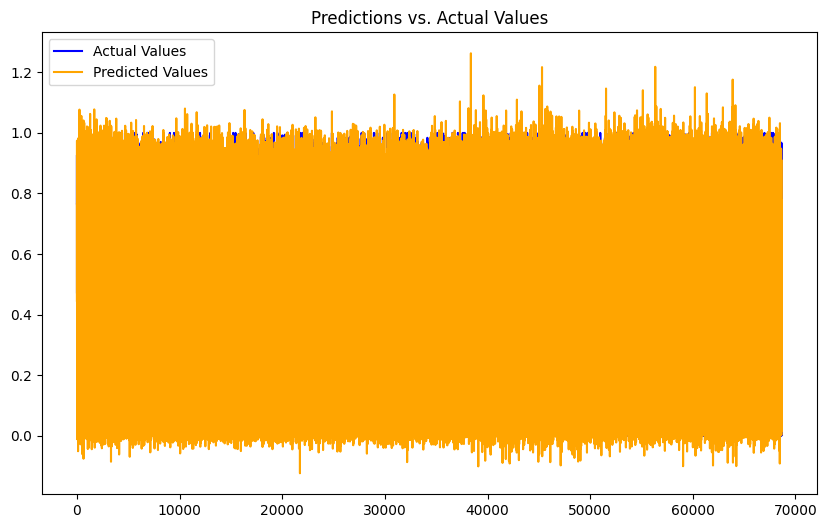

In [ ]:
# Visualization: Predictions vs. Actual
plt.figure(figsize=(10, 6))
plt.plot(actual, label="Actual Values", color='blue')
plt.plot(predictions, label="Predicted Values", color='orange')
plt.title("Predictions vs. Actual Values")
plt.legend()
plt.show()

The figure shows a graph labeled "Predictions VS Actual Values " it plot two sets of value :
	1.	Actual Values (blue line)
	2.	Predicted Values (orange line)

The x-axis represents data points or samples, ranging from 0 to approximately 70,000. The y-axis represents the values of both the predictions and the actual data, ranging from 0 to slightly above 1.2.

Observations:

	•	The orange line (predicted values) seems to closely overlap the blue line (actual values), indicating a strong correlation between the predictions and the actual data.
	•	There are some deviations visible as occasional spikes where the predicted values differ slightly from the actual values.
	•	The overall alignment suggests the predictive model is performing well with minor errors.

